<a href="https://colab.research.google.com/github/devisree6330/dc_minip/blob/pakshal-nagda_da24b045/Vision_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
import torchvision.transforms as T

from PIL import Image
import matplotlib.pyplot as plt

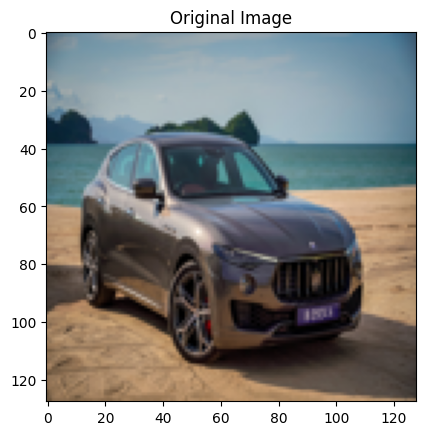

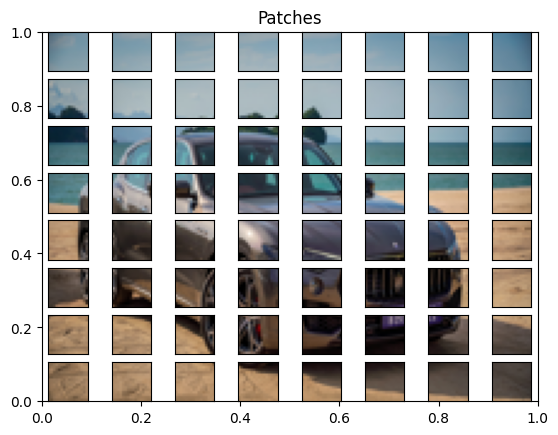

In [2]:
# Patching an example image
import urllib.request
urllib.request.urlretrieve(
  'https://drive.google.com/uc?id=1h6ODFoGIMLgLGOiTdWz7CKWdJPOjUiu8',
   "car.png")
image = Image.open('car.png').resize((128,128))
x = np.array(image)
P = 16
C = 3
patches = x.reshape(x.shape[0]//P, P, x.shape[1]//P, P, C).swapaxes(1,2)

plt.imshow(x)
plt.title('Original Image')

plt.figure()
plt.title('Patches')
for i in range(x.shape[0]//P):
  for j in range(x.shape[1]//P):
    plt.subplot(x.shape[0]//P, x.shape[1]//P, i*x.shape[1]//P+j+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(patches[i,j])
plt.show()

In [3]:
# Flattening the patches into embeddings
x_p = patches.reshape(-1, P * P * C)
print("Flattened Patch Shape:", x_p.shape)
# x_p has 64 rows representing patches or 'words' and 16 x 16 x 3 = 768 columns representing the embedding of each word.

Flattened Patch Shape: (64, 768)


In [4]:
class SelfAttention(nn.Module):
    def __init__(self, embedding_dim=768, key_dim=64):
        super().__init__()

        self.embedding_dim = embedding_dim   # D -> embedding dimensionaltiy
        self.key_dim = key_dim               # D_h -> key, query, value dimensionality

        # U_kqv weight matrix
        self.W = nn.Parameter(torch.randn(embedding_dim, 3*key_dim))

    def forward(self, x):
        key_dim = self.key_dim

        # get query, key and value projection
        qkv = torch.matmul(x, self.W)

        # get query, key, value
        q = qkv[:, :, :key_dim]
        k = qkv[:, :, key_dim:key_dim*2 ]
        v = qkv[:, :, key_dim*2:]

        # compute dot product of the all query with all keys
        k_T = torch.transpose(k, -2, -1)   # get transpose of key
        dot_products = torch.matmul(q, k_T)

        # divide each by √Dh
        scaled_dot_products = dot_products / np.sqrt(key_dim)

        # apply a softmax function to obtain attention weights -> A
        attention_weights = F.softmax(scaled_dot_products, dim=1)

        # get weighted values
        weighted_values = torch.matmul(attention_weights, v)

        return weighted_values

In [5]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embedding_dim=768, num_heads=12):
        super().__init__()

        self.num_heads = num_heads            # set number of heads (k)
        self.embedding_dim = embedding_dim    # set dimensionality

        assert embedding_dim % num_heads == 0   # dimensionality should be divisible by number of heads
        self.key_dim = embedding_dim // num_heads   # set key,query and value dimensionality

        # init self-attentions
        self.attention_list = [SelfAttention(embedding_dim, self.key_dim) for _ in range(num_heads)]
        self.multi_head_attention = nn.ModuleList(self.attention_list)

        # init U_msa weight matrix
        self.W = nn.Parameter(torch.randn(num_heads * self.key_dim, embedding_dim))

    def forward(self, x):
        # compute self-attention scores of each head
        attention_scores = [attention(x) for attention in self.multi_head_attention]

        # concat attentions
        Z = torch.cat(attention_scores, -1)

        # compute multi-head attention score
        attention_score = torch.matmul(Z, self.W)

        return attention_score

In [6]:
class MultiLayerPerceptron(nn.Module):
    def __init__(self, embedding_dim=768, hidden_dim=3072):
        super().__init__()
        self.mlp = nn.Sequential(
                            nn.Linear(embedding_dim, hidden_dim),
                            nn.GELU(),
                            nn.Linear(hidden_dim, embedding_dim)
                   )

    def forward(self, x):
        return self.mlp(x)

In [7]:
class TransformerEncoder(nn.Module):
    def __init__(self, embedding_dim=768, num_heads=12, hidden_dim=3072, dropout_prob=0.1):
        super().__init__()

        self.MSA = MultiHeadSelfAttention(embedding_dim, num_heads)
        self.MLP = MultiLayerPerceptron(embedding_dim, hidden_dim)

        self.layer_norm1 = nn.LayerNorm(embedding_dim)
        self.layer_norm2 = nn.LayerNorm(embedding_dim)

        self.dropout1 = nn.Dropout(p=dropout_prob)
        self.dropout2 = nn.Dropout(p=dropout_prob)
        self.dropout3 = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        x = x + self.dropout2(self.MSA(self.layer_norm1(self.dropout1(x))))
        return x + self.dropout3(self.MLP(self.layer_norm2(x)))

In [8]:
class MLPHead(nn.Module):
    def __init__(self, embedding_dim=768, num_classes=10, fine_tune=False):
        super().__init__()
        self.num_classes = num_classes

        if not fine_tune:
            # hidden layer with tanh activation function
            self.mlp_head = nn.Sequential(
                                    nn.Linear(embedding_dim, 3072),  # hidden layer
                                    nn.Tanh(),
                                    nn.Linear(3072, num_classes)    # output layer
                            )
        else:
            # single linear layer
            self.mlp_head = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        return self.mlp_head(x)

In [9]:
class VisionTransformer(nn.Module):
    def __init__(self, patch_size=16, image_size=224, channel_size=3,
                     num_layers=12, embedding_dim=768, num_heads=12, hidden_dim=3072,
                            dropout_prob=0.1, num_classes=10, fine_tune=False):
        super().__init__()

        self.patch_size = patch_size
        self.channel_size = channel_size
        self.num_layers = num_layers
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.hidden_dim = hidden_dim
        self.dropout_prob = dropout_prob
        self.num_classes = num_classes

        # get number of patches of the image
        self.num_patches = int(image_size ** 2 / patch_size ** 2)   # height * width / patch size ^ 2

        # trainable linear projection for mapping dimension of patches (weight matrix E)
        self.W = nn.Parameter(
                    torch.randn(patch_size * patch_size * channel_size, embedding_dim))

        # position embeddings (E_pos)
        self.pos_embedding = nn.Parameter(torch.randn(self.num_patches + 1, embedding_dim))

        # learnable class token embedding (x_class)
        self.class_token = nn.Parameter(torch.rand(1, embedding_dim))

        # stack transformer encoder layers
        transformer_encoder_list = [
            TransformerEncoder(embedding_dim, num_heads, hidden_dim, dropout_prob)
                    for _ in range(num_layers)]
        self.transformer_encoder_layers = nn.Sequential(*transformer_encoder_list)

        # mlp head
        self.mlp_head = MLPHead(embedding_dim, num_classes, fine_tune)

    def forward(self, x):
        # get patch size and channel size
        P, C = self.patch_size, self.channel_size

        # split image into patches
        patches = x.unfold(1, C, C).unfold(2, P, P).unfold(3, P, P)
        patches = patches.contiguous().view(patches.size(0), -1, C * P * P).float()

        # linearly embed patches
        patch_embeddings = torch.matmul(patches , self.W)

        # add class token
        batch_size = patch_embeddings.shape[0]
        patch_embeddings = torch.cat((self.class_token.repeat(batch_size, 1, 1), patch_embeddings), 1)

        # add positional embedding
        patch_embeddings += self.pos_embedding

        # feed patch embeddings into a stack of Transformer encoders
        transformer_encoder_output = self.transformer_encoder_layers(patch_embeddings)

        # extract [class] token from encoder output
        output_class_token = transformer_encoder_output[:, 0]

        # pass token through mlp head for classification
        y = self.mlp_head(output_class_token)

        return y

In [10]:
import torchvision
from torchvision import datasets

from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler

import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

In [11]:
# Load data
#
# We will use a subset of CIFAR10 dataset

image_size = 224

# define transform
transform = T.Compose([ T.Resize(image_size), T.ToTensor() ])

torchvision.datasets.CIFAR10.url="http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"

# init CIFAR10 training and test datasets
trainset = datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
testset = datasets.CIFAR10(root='data', train=False, download=True, transform=transform)

# get class names
classes = trainset.classes

# get a subset of the trainset and test set
trainset = torch.utils.data.Subset(trainset, list(range(5000)))
testset = torch.utils.data.Subset(testset, list(range(1000)))

# output classes
classes

100%|██████████| 170M/170M [00:03<00:00, 45.7MB/s]


['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [12]:
# define data loaders
batch_size = 16

# percentage of training set to use as validation
valid_size = 0.2

# get training indices that wil be used for validation
train_size = len(trainset)
indices = list(range(train_size))
np.random.shuffle(indices)
split = int(np.floor(valid_size * train_size))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers to obtain training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders
train_loader = DataLoader(trainset, batch_size=batch_size, sampler=train_sampler)
valid_loader = DataLoader(trainset, batch_size=batch_size, sampler=valid_sampler)
test_loader = DataLoader(testset, batch_size=batch_size)

In [13]:
# print out classes statistics

# get all training samples labels
train_labels = [labels for i, (images, labels) in enumerate(train_loader)]
train_labels = torch.cat((train_labels), 0)
train_labels_count = train_labels.unique(return_counts=True)

# print(train_labels_count)

print('The number of samples per classes in training dataset:\n')
for label, count in zip(train_labels_count[0], train_labels_count[1]):
    print('\t {}: {}'.format(label, count))

# get all test samples labels
test_labels = [labels for i, (images, labels) in enumerate(test_loader)]
test_labels = torch.cat((test_labels), 0)
test_labels_count = test_labels.unique(return_counts=True)

print()
print('The number of samples per classes in test dataset:\n')
for label, count in zip(test_labels_count[0], test_labels_count[1]):
    print('\t {}: {}'.format(label, count))

The number of samples per classes in training dataset:

	 0: 408
	 1: 374
	 2: 434
	 3: 381
	 4: 416
	 5: 382
	 6: 411
	 7: 383
	 8: 418
	 9: 393

The number of samples per classes in test dataset:

	 0: 103
	 1: 89
	 2: 100
	 3: 103
	 4: 90
	 5: 86
	 6: 112
	 7: 102
	 8: 106
	 9: 109


In [14]:
ViT = VisionTransformer()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ViT.parameters(), betas=(0.9, 0.999), weight_decay=0.1, lr=1e-4)

In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [17]:
epochs = 7
train_losses = []
val_losses = []
ViT = ViT.to(device)
for epoch in range(epochs):
  train_loss = val_loss = 0
  ViT.train()
  for images, targets in train_loader:
    images = images.to(device)
    targets = targets.to(device)
    optimizer.zero_grad()
    preds = ViT(images)
    loss = criterion(preds, targets)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
  ViT.eval()
  for images, targets in valid_loader:
    images = images.to(device)
    targets = targets.to(device)
    with torch.no_grad():
      preds = ViT(images)
      loss = criterion(preds, targets)
      val_loss += loss.item()
  train_loss /= len(train_loader)
  val_loss /= len(valid_loader)
  train_losses.append(train_loss)
  val_losses.append(val_loss)
  print(f'Epoch: {epoch} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')

Epoch: 0 | Train Loss: 2.286289 | Val Loss: 2.285734
Epoch: 1 | Train Loss: 2.280329 | Val Loss: 2.249699
Epoch: 2 | Train Loss: 2.287802 | Val Loss: 2.231002
Epoch: 3 | Train Loss: 2.287077 | Val Loss: 2.283121
Epoch: 4 | Train Loss: 2.293807 | Val Loss: 2.335075
Epoch: 5 | Train Loss: 2.292875 | Val Loss: 2.279741
Epoch: 6 | Train Loss: 2.300068 | Val Loss: 2.338283


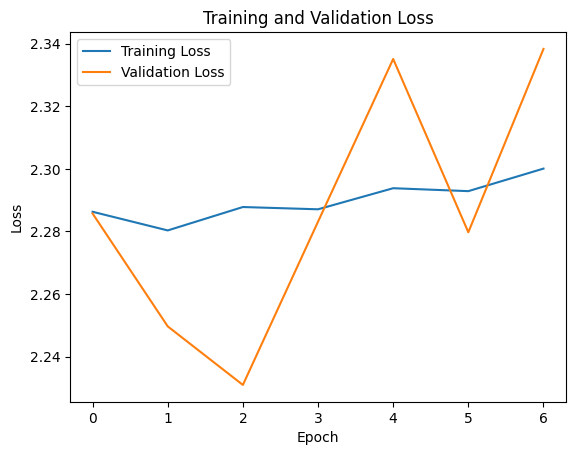

In [18]:
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [24]:
ViT.eval()

test_loss = 0
test_acc = 0
n_class = len(classes)
class_correct = np.zeros(n_class)
class_total = np.zeros(n_class)

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        targets = targets.to(device)

        preds = ViT(images)

        loss = criterion(preds, targets)
        test_loss += loss.item()

        _, predicted = torch.max(preds, 1)
        correct = (predicted == targets)
        test_acc += correct.sum().item()

        for c in range(n_class):
            class_total[c] += (targets == c).sum().item()
            class_correct[c] += (correct & (targets == c)).sum().item()

test_loss /= len(test_loader)
test_acc /= len(test_loader.dataset)

print(f'Test Loss: {test_loss:.3f} | Test Accuracy: {test_acc*100:.3f}%')

class_acc = class_correct / class_total
for i in range(n_class):
    print(f'Accuracy of {classes[i]}:\t{class_acc[i]*100:.3f}%\t({class_correct[i]}/{class_total[i]})')

Test Loss: 2.329 | Test Accuracy: 10.700%
Accuracy of airplane:	0.000%	(0.0/103.0)
Accuracy of automobile:	0.000%	(0.0/89.0)
Accuracy of bird:	95.000%	(95.0/100.0)
Accuracy of cat:	0.000%	(0.0/103.0)
Accuracy of deer:	0.000%	(0.0/90.0)
Accuracy of dog:	0.000%	(0.0/86.0)
Accuracy of frog:	0.000%	(0.0/112.0)
Accuracy of horse:	0.000%	(0.0/102.0)
Accuracy of ship:	11.321%	(12.0/106.0)
Accuracy of truck:	0.000%	(0.0/109.0)
